In [2]:
# 5장 회귀 - 실전 실습 - 자전거 대여 및 집값 예측하기

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

train = pd.read_csv("../data/bike_train.csv")
test = pd.read_csv("../data/bike_test.csv")

print(train.shape, test.shape)
train.info()

(10886, 12) (6493, 9)
<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [3]:
# datetime을 pd.to_datetime 타입으로 변환
train["datetime"] = pd.to_datetime(train["datetime"])
test["datetime"] = pd.to_datetime(test["datetime"])
train.dtypes

datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object

In [ ]:
# 날짜를 년/월/일/시 로 분할하여 새 peature 만들기
train["year"] = train.datetime.apply(lambda x: x.year)
train["month"] = train.datetime.apply(lambda x: x.month)
train["day"] = train.datetime.apply(lambda x: x.day)
train["hour"] = train.datetime.apply(lambda x: x.hour)

test["year"] = test.datetime.apply(lambda x: x.year)
test["month"] = test.datetime.apply(lambda x: x.month)
test["day"] = test.datetime.apply(lambda x: x.day)
test["hour"] = test.datetime.apply(lambda x: x.hour)

train[["datetime", "year", "month", "day", "hour"]].head()

,datetime,year,month,day,hour
0,2011-01-01 00:00:00,2011,1,1,0
1,2011-01-01 01:00:00,2011,1,1,1
2,2011-01-01 02:00:00,2011,1,1,2
3,2011-01-01 03:00:00,2011,1,1,3
4,2011-01-01 04:00:00,2011,1,1,4


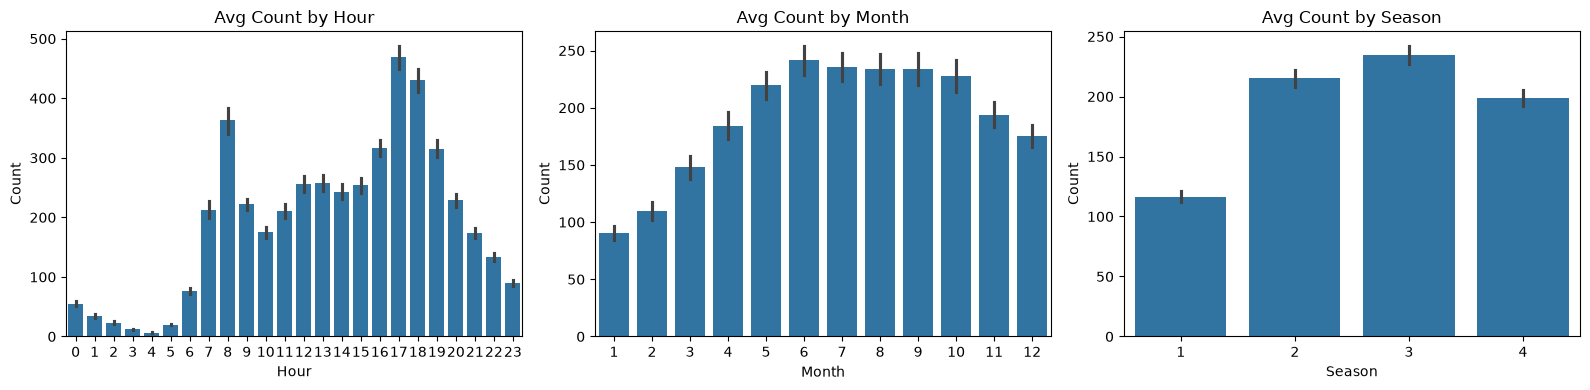

In [5]:
fig, axs = plt.subplots(figsize=(16, 4), ncols=3)

sns.barplot(x = 'hour', y = 'count', data = train, ax = axs[0])
axs[0].set_title("Avg Count by Hour")
axs[0].set_xlabel("Hour")
axs[0].set_ylabel("Count")

sns.barplot(x = 'month', y = 'count', data = train, ax = axs[1])
axs[1].set_title("Avg Count by Month")
axs[1].set_xlabel("Month")
axs[1].set_ylabel("Count")

sns.barplot(x = 'season', y = 'count', data = train, ax = axs[2])
axs[2].set_title("Avg Count by Season")
axs[2].set_xlabel("Season")
axs[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

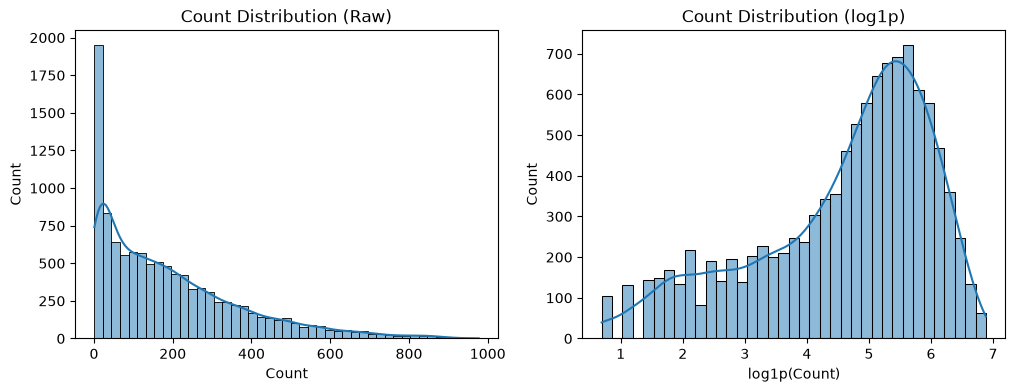

In [6]:
fig, axs = plt.subplots(figsize=(12, 4), ncols=2)

sns.histplot(train["count"], ax=axs[0], kde=True)
axs[0].set_title("Count Distribution (Raw)")
axs[0].set_xlabel("Count")

sns.histplot(np.log1p(train["count"]), ax=axs[1], kde=True)
axs[1].set_title("Count Distribution (log1p)")
axs[1].set_xlabel("log1p(Count)")

plt.show()

In [ ]:
drop_cols = ["datetime", "casual", "registered"] # 불필요한 컬럼 drop 으로 제거

X_features = train.drop(["count"] + drop_cols, axis = 1)
y_target = train["count"]
X_test_final = test.drop(["datetime"], axis = 1)

print(X_features.columns.tolist())
print(X_test_final.columns.tolist())

['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']


In [8]:
y_target_log = np.log1p(y_target)

In [ ]:
# RMSLE 평가 함수 정의

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, a_min = 0, a_max = None)
    log_true = np.log1p(y_true)
    log_pred = np.log1p(y_pred)
    return np.sqrt(mean_squared_error(log_true, log_pred))

def evaluate_regr(y_true, y_pred):
    rmsle_val = rmsle(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_val = mean_absolute_error(y_true, y_pred)
    print(f"RMSLE: {rmsle_val:.4f}, RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}")

In [ ]:
# LinearRegression 기본학습, 평가
X_train, X_val, y_train_log, y_val_log = train_test_split(X_features,
                                                          y_target_log,
                                                          test_size = 0.3,
                                                          random_state = 42)

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train_log)

pred_log = lr_reg.predict(X_val)

# 로그 스케일 학습 > expm1사용 원래 단위 복원 후 평가
pred = np.expm1(pred_log)
y_val = np.expm1(y_val_log)

evaluate_regr(y_val, pred)

RMSLE: 1.0202, RMSE: 160.7296, MAE: 108.2357


In [ ]:
# 함수생성, 여러 회귀모델의 비교 (교차검증 및 학습시간의 측정)
def get_model_cv_prediction(model, X_features, y_target_log):
    start = time.time()
    neg_mse_scores = cross_val_score(model,
                                     X_features,
                                     y_target_log,
                                     scoring = "neg_mean_squared_error",
                                     cv = 5)
    elapsed = time.time() - start
    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)
    print(f"{model.__class__.__name__:25s} RMSE(log) = {avg_rmse:.4f}   time = {elapsed:.1f}s")
    return model.__class__.__name__, avg_rmse, elapsed

dt_reg = DecisionTreeRegressor(random_state = 42, max_depth = 4)
rf_reg = RandomForestRegressor(random_state = 42, n_estimators = 1000, n_jobs = -1)
gb_reg = GradientBoostingRegressor(random_state = 42, n_estimators = 1000)
xgb_reg = XGBRegressor(n_estimators = 1000, random_state = 42)
lgb_reg = LGBMRegressor(n_estimators = 1000, random_state = 42)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]

result = []
for model in models:
    result.append(get_model_cv_prediction(model, X_features, y_target_log))

result_df = pd.DataFrame(result, columns = ["model", "rmse", "seconds"]).sort_values("rmse")

print(result_df)

DecisionTreeRegressor     RMSE(log) = 0.7890   time = 0.1s
RandomForestRegressor     RMSE(log) = 0.4675   time = 27.8s
GradientBoostingRegressor RMSE(log) = 0.4163   time = 35.7s
XGBRegressor              RMSE(log) = 0.4442   time = 7.9s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001050 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 12
[LightGBM] [Info] Start training from score 4.753723
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points in the train set: 8709, number of used features: 12
[LightGBM] [Info] Start training from score 4.568295
[LightGBM] [Info] 

In [12]:
param_dist = {
    "n_estimators": [500, 1000, 1500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample" : [0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state = 42),
    param_distributions = param_dist,
    n_iter = 15,
    scoring = "neg_mean_squared_error",
    cv = 3,
    random_state = 42,
    n_jobs = -1
)

start = time.time()
random_search.fit(X_features, y_target_log)
print(F"Tuning time: {time.time()-start:.1f}s")

print("Best params:", random_search.best_params_)
print("Best RMSE(log):", np.sqrt(-random_search.best_score_))

best_model = random_search.best_estimator_

Tuning time: 72.9s
Best params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05}
Best RMSE(log): 0.46051663983680735


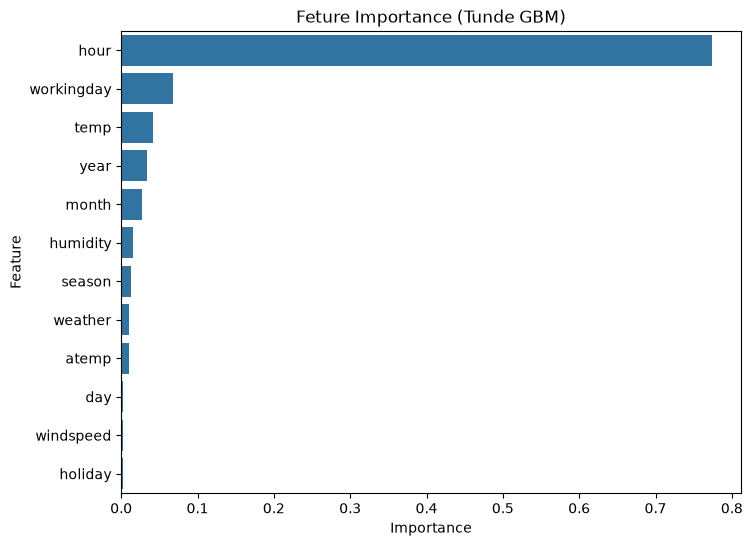

hour          0.773538
workingday    0.068495
temp          0.041486
year          0.033885
month         0.027095
humidity      0.016049
season        0.012478
weather       0.010022
atemp         0.009686
day           0.002942
windspeed     0.002482
holiday       0.001842
dtype: float64


In [17]:
best_model.fit(X_features, y_target_log)

feature_series = pd.Series(best_model.feature_importances_, index = X_features.columns)
feature_series = feature_series.sort_values(ascending = False)

plt.figure(figsize = (8, 6))
sns.barplot(x = feature_series.values,
            y= feature_series.index)
plt.title("Feture Importance (Tunde GBM)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print(feature_series)

In [18]:
best_model.fit(X_train, y_train_log)
pred_log_best = best_model.predict(X_val)
pred_best = np.expm1(pred_log_best)

print("[Tuned GradientBoosting]")
evaluate_regr(y_val, pred_best)

print("\n[Baseline : LinearRegression]")
evaluate_regr(y_val, pred)

[Tuned GradientBoosting]
RMSLE: 0.3077, RMSE: 45.0865, MAE: 28.2088

[Baseline : LinearRegression]
RMSLE: 1.0202, RMSE: 160.7296, MAE: 108.2357


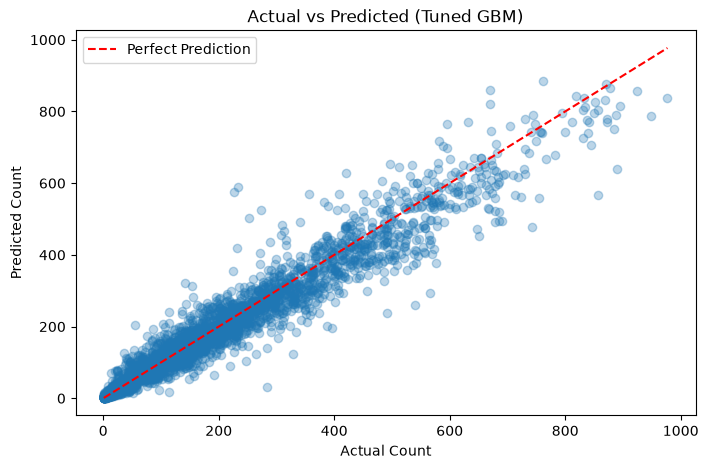

In [19]:
plt.figure(figsize = (8, 5))
plt.scatter(y_val, pred_best, alpha = 0.3)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         "r--", label = "Perfect Prediction")
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted (Tuned GBM)")
plt.legend()
plt.show()

In [20]:
final_model = random_search.best_estimator_
final_model.fit(X_features, y_target_log)

final_pred_log = final_model.predict(X_test_final)
final_pred = np.expm1(final_pred_log)

submission = pd.DataFrame({
    "datetime": test["datetime"],
    "count": final_pred
})

submission.head()

,datetime,count
0,2011-01-20 00:00:00,9.272055
1,2011-01-20 01:00:00,4.645659
2,2011-01-20 02:00:00,2.346803
3,2011-01-20 03:00:00,1.619220
4,2011-01-20 04:00:00,1.530024
